# Uber AV Supply Shock Simulation

This notebook models how rider wait times respond to a sudden loss of vehicle supply, using the Uber-Waymo Phoenix partnership ending (June 2026) as the motivating event. NYC TLC trip data is used as a proxy, since Phoenix-level public data is not available.

## 1. Load and inspect the data

In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet("../data/fhvhv_tripdata_2025-04.parquet")

In [3]:
df.shape

(19753983, 25)

## 2. Filter to Uber trips only

The HVFHV dataset covers multiple providers. HV0003 corresponds to Uber and HV0005 to Lyft.

In [4]:
df = df[df["hvfhs_license_num"] == "HV0003"].reset_index(drop=True)

In [5]:
df.shape

(14360522, 25)

## 3. Join the taxi zone lookup table

In [6]:
zones = pd.read_csv("../data/taxi_zone_lookup.csv")

In [7]:
df = df.merge(
    zones.rename(columns={
        "LocationID": "PULocationID",
        "Borough": "PU_Borough",
        "Zone": "PU_Zone"
    })[["PULocationID", "PU_Borough", "PU_Zone"]],
    on="PULocationID",
    how="left"
)

In [8]:
df.shape

(14360522, 27)

## 4. Extract time features

In [9]:
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_date"] = df["pickup_datetime"].dt.date
df["pickup_dow"] = df["pickup_datetime"].dt.day_name()  # day of week

In [10]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 14360522 entries, 0 to 14360521
Data columns (total 30 columns):
 #   Column                Dtype         
---  ------                -----         
 0   hvfhs_license_num     str           
 1   dispatching_base_num  str           
 2   originating_base_num  str           
 3   request_datetime      datetime64[us]
 4   on_scene_datetime     datetime64[us]
 5   pickup_datetime       datetime64[us]
 6   dropoff_datetime      datetime64[us]
 7   PULocationID          int32         
 8   DOLocationID          int32         
 9   trip_miles            float64       
 10  trip_time             int64         
 11  base_passenger_fare   float64       
 12  tolls                 float64       
 13  bcf                   float64       
 14  sales_tax             float64       
 15  congestion_surcharge  float64       
 16  airport_fee           float64       
 17  tips                  float64       
 18  driver_pay            float64       
 19  shared_re

## 5. Reduce memory footprint

Dropping unused columns and downcasting types, since the raw dataframe was using close to 4.2 GB of memory.

In [11]:
cols_to_keep = [
    "PULocationID", "DOLocationID", "PU_Borough", "PU_Zone",
    "pickup_datetime", "dropoff_datetime", "request_datetime",
    "trip_miles", "trip_time",
    "base_passenger_fare", "tips", "driver_pay",
    "shared_request_flag",
    "pickup_hour", "pickup_date", "pickup_dow"
]

df = df[cols_to_keep]
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 14360522 entries, 0 to 14360521
Data columns (total 16 columns):
 #   Column               Dtype         
---  ------               -----         
 0   PULocationID         int32         
 1   DOLocationID         int32         
 2   PU_Borough           str           
 3   PU_Zone              str           
 4   pickup_datetime      datetime64[us]
 5   dropoff_datetime     datetime64[us]
 6   request_datetime     datetime64[us]
 7   trip_miles           float64       
 8   trip_time            int64         
 9   base_passenger_fare  float64       
 10  tips                 float64       
 11  driver_pay           float64       
 12  shared_request_flag  str           
 13  pickup_hour          int32         
 14  pickup_date          object        
 15  pickup_dow           str           
dtypes: datetime64[us](3), float64(4), int32(3), int64(1), object(1), str(4)
memory usage: 2.4 GB


In [12]:
df["PULocationID"] = df["PULocationID"].astype("int16")
df["DOLocationID"] = df["DOLocationID"].astype("int16")
df["trip_miles"] = df["trip_miles"].astype("float32")
df["trip_time"] = df["trip_time"].astype("int32")
df["base_passenger_fare"] = df["base_passenger_fare"].astype("float32")
df["tips"] = df["tips"].astype("float32")
df["driver_pay"] = df["driver_pay"].astype("float32")
df["pickup_hour"] = df["pickup_hour"].astype("int8")

In [13]:
for col in ["PU_Borough", "PU_Zone", "pickup_dow", "shared_request_flag"]:
    df[col] = df[col].astype("category")

In [14]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 14360522 entries, 0 to 14360521
Data columns (total 16 columns):
 #   Column               Dtype         
---  ------               -----         
 0   PULocationID         int16         
 1   DOLocationID         int16         
 2   PU_Borough           category      
 3   PU_Zone              category      
 4   pickup_datetime      datetime64[us]
 5   dropoff_datetime     datetime64[us]
 6   request_datetime     datetime64[us]
 7   trip_miles           float32       
 8   trip_time            int32         
 9   base_passenger_fare  float32       
 10  tips                 float32       
 11  driver_pay           float32       
 12  shared_request_flag  category      
 13  pickup_hour          int8          
 14  pickup_date          object        
 15  pickup_dow           category      
dtypes: category(4), datetime64[us](3), float32(4), int16(2), int32(1), int8(1), object(1)
memory usage: 1.3 GB


In [15]:
df["pickup_date"] = pd.to_datetime(df["pickup_date"])

## 6. Build the wait time metric and the zone-hour baseline table

In [16]:
# Wait time = request to pickup (in seconds), this is your real wait metric
df["wait_time_sec"] = (df["pickup_datetime"] - df["request_datetime"]).dt.total_seconds()

# Filter out bad/negative wait times (data errors)
upper_limit = df["wait_time_sec"].quantile(0.99)
df = df[(df["wait_time_sec"] >= 0) & (df["wait_time_sec"] <= upper_limit)]

# Baseline aggregation: zone + hour level
baseline = df.groupby(["PULocationID", "PU_Zone", "PU_Borough", "pickup_hour"], observed=True).agg(
    trip_count=("PULocationID", "count"),
    avg_wait_sec=("wait_time_sec", "mean"),
    avg_fare=("base_passenger_fare", "mean"),
    avg_trip_miles=("trip_miles", "mean"),
    avg_driver_pay=("driver_pay", "mean")
).reset_index()

baseline.shape

(6170, 9)

In [17]:
baseline.sort_values("trip_count", ascending=False).head(10)

,PULocationID,PU_Zone,PU_Borough,pickup_hour,trip_count,avg_wait_sec,avg_fare,avg_trip_miles,avg_driver_pay
3048,132,JFK Airport,Queens,22,18375,446.269986,68.965149,18.025288,53.575771
3191,138,LaGuardia Airport,Queens,21,18372,507.583987,58.284630,12.161344,39.624340
3188,138,LaGuardia Airport,Queens,18,18040,311.765798,61.606812,11.913820,41.201088
3189,138,LaGuardia Airport,Queens,19,18036,367.065425,60.074677,12.273906,40.194664
3180,138,LaGuardia Airport,Queens,10,17954,277.835134,63.308071,11.351455,41.463726
3193,138,LaGuardia Airport,Queens,23,17608,492.436222,53.195900,11.705920,37.871330
3190,138,LaGuardia Airport,Queens,20,17473,416.777657,57.463974,12.140174,39.002762
3184,138,LaGuardia Airport,Queens,14,17121,284.292214,67.404869,11.628880,44.823250
3186,138,LaGuardia Airport,Queens,16,16991,281.832912,67.750763,11.516564,45.465706
3049,132,JFK Airport,Queens,23,16753,445.225989,68.215645,18.317276,53.294018


Average wait time at these airport zones (roughly 280 to 500 seconds, or about 4.7 to 8.4 minutes) is noticeably higher than other zones. Airports are naturally supply constrained due to limited curb/queue space, so this is a useful reference point later on.

The idea here is that wait time itself is a proxy for supply-demand imbalance. When supply is tight relative to demand, wait time rises, so wait time can act as an implicit signal of that imbalance even without a direct measure of supply.

## 7. Explore the relationship between demand and wait time

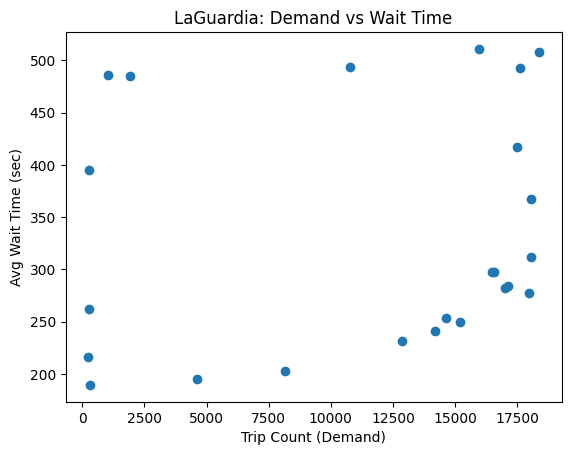

In [18]:
import matplotlib.pyplot as plt

sample = baseline[baseline["PU_Zone"] == "LaGuardia Airport"]
plt.scatter(sample["trip_count"], sample["avg_wait_sec"])
plt.xlabel("Trip Count (Demand)")
plt.ylabel("Avg Wait Time (sec)")
plt.title("LaGuardia: Demand vs Wait Time")
plt.show()

This U-shape looks like a classic confounding variable problem: pickup_hour.

- Very low trip counts likely correspond to late-night/red-eye hours (2 to 4 AM). Few passengers, but also very few drivers on the road, so the few people waiting still wait a while.
- Mid-range trip counts are probably steady daytime off-peak hours, with decent driver supply relative to demand, so wait times are low.
- High trip counts are true peak hours (roughly 6 to 10 PM), where demand outpaces supply and wait time climbs again. This is the queueing effect originally expected.

In [19]:
from scipy import stats

# Simple linear fit for LaGuardia as example
slope, intercept, r_value, p_value, std_err = stats.linregress(
    sample["trip_count"], sample["avg_wait_sec"]
)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.2f}, R²: {r_value**2:.3f}")

Slope: 0.0022, Intercept: 306.10, R²: 0.019


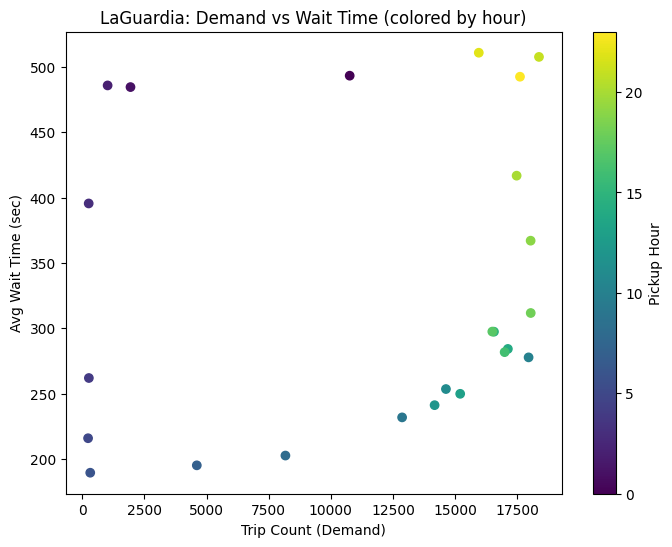

In [20]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(sample["trip_count"], sample["avg_wait_sec"], 
                       c=sample["pickup_hour"], cmap="viridis")
plt.colorbar(scatter, label="Pickup Hour")
plt.xlabel("Trip Count (Demand)")
plt.ylabel("Avg Wait Time (sec)")
plt.title("LaGuardia: Demand vs Wait Time (colored by hour)")
plt.show()

In [21]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import statsmodels.api as sm

X = sample[["trip_count", "pickup_hour"]]
X = sm.add_constant(X)
y = sample["avg_wait_sec"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           avg_wait_sec   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                 -0.055
Method:                 Least Squares   F-statistic:                    0.4044
Date:                Sun, 12 Jul 2026   Prob (F-statistic):              0.672
Time:                        01:20:29   Log-Likelihood:                -146.38
No. Observations:                  24   AIC:                             298.8
Df Residuals:                      21   BIC:                             302.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         298.1881     46.878      6.361      

R squared = 0.037, meaning this linear model explains almost none of the variance. Adjusted R squared is actually negative (-0.055), which means the model performs worse than just guessing the average. That is a strong sign the straight-line fit is the wrong shape for this data.

Neither predictor is statistically significant: trip_count has p = 0.879, pickup_hour has p = 0.541. With only 24 observations (one per hour, for LaGuardia), sample size is part of the issue, but the bigger problem is the U-shape itself. No straight line can capture that pattern regardless of sample size.

Conclusion: hour cannot be treated as a simple continuous linear variable. The scatter plot showed this clearly: wait time is high at low hours (0 to 2 AM), dips in the middle of the day, and rises again in the evening. A single slope coefficient cannot represent a "high, low, high" pattern.

## 8. Fix the model by bucketing hours into time-of-day segments

In [23]:
def time_bucket(hour):
    if 0 <= hour <= 4:
        return "Overnight"
    elif 5 <= hour <= 9:
        return "Morning"
    elif 10 <= hour <= 15:
        return "Midday"
    elif 16 <= hour <= 20:
        return "Evening Peak"
    else:
        return "Night"

sample["time_bucket"] = sample["pickup_hour"].apply(time_bucket)

X = pd.get_dummies(sample[["trip_count", "time_bucket"]], columns=["time_bucket"], drop_first=True)
X = sm.add_constant(X.astype(float))
y = sample["avg_wait_sec"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           avg_wait_sec   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     18.22
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           1.76e-06
Time:                        01:20:29   Log-Likelihood:                -125.21
No. Observations:                  24   AIC:                             262.4
Df Residuals:                      18   BIC:                             269.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   229.19

Overnight and late-night hours have significantly worse wait times than even the evening rush. That is a genuinely interesting, non-obvious result. It is less about how many people are requesting rides, and more about how few drivers are willing to work those hours at all, regardless of demand volume. This points to a supply-availability story rather than a demand-volume story.

Two caveats worth flagging:

- Small sample size: only 24 hourly observations for one zone, estimating 6 parameters from that. Treat these results as suggestive rather than definitive, which is why some p-values sit in the 0.08 to 0.10 range.
- High condition number (1.31e+05): trip_count and time_bucket are correlated, since demand naturally varies by time of day, which inflates uncertainty in individual coefficients even though the overall model fits well.

## 9. Full model across all zones and boroughs

In [24]:
baseline["time_bucket"] = baseline["pickup_hour"].apply(time_bucket)

X = pd.get_dummies(baseline[["trip_count", "time_bucket", "PU_Zone"]], 
                    columns=["time_bucket", "PU_Zone"], drop_first=True)
X = sm.add_constant(X.astype(float))
y = baseline["avg_wait_sec"]

model_full = sm.OLS(y, X).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:           avg_wait_sec   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     48.12
Date:                Sun, 12 Jul 2026   Prob (F-statistic):               0.00
Time:                        01:20:29   Log-Likelihood:                -30660.
No. Observations:                6170   AIC:                         6.185e+04
Df Residuals:                    5907   BIC:                         6.362e+04
Df Model:                         262                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [25]:
X = pd.get_dummies(baseline[["trip_count", "time_bucket", "PU_Borough"]], 
                    columns=["time_bucket", "PU_Borough"], drop_first=True)

X = sm.add_constant(X.astype(float))

y = baseline["avg_wait_sec"]

model_borough = sm.OLS(y, X).fit()

print(model_borough.summary())

                            OLS Regression Results                            
Dep. Variable:           avg_wait_sec   R-squared:                       0.339
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     350.4
Date:                Sun, 12 Jul 2026   Prob (F-statistic):               0.00
Time:                        01:20:29   Log-Likelihood:                -32909.
No. Observations:                6170   AIC:                         6.584e+04
Df Residuals:                    6160   BIC:                         6.591e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

R squared = 0.339, lower than the single-zone model (0.681). That makes sense: boroughs are a much coarser grouping than 265 individual zones, so less location-specific variation is captured. It is a reasonable tradeoff for stability, and 0.339 is still a solid result for real-world operational data.

One notable change: the trip_count coefficient flipped sign, from +0.0024 to -0.0027 (both highly significant, p < 0.001). This is not an error, it is a classic confounding effect. In the zone-level model, high-trip zones (like Manhattan) happened to correlate with patterns that pushed the coefficient positive. Once borough is controlled for, the question becomes: within the same borough, does having more trips in a given hour predict a shorter or longer wait? The answer is slightly shorter, since more trips in a given area likely also means more drivers nearby and more efficient matching. That is a more intuitive marketplace story: demand alone, once location is held constant, is a mild efficiency signal rather than a scarcity signal.

Borough effects are sensible and significant:

- Manhattan: -37.5 sec vs Bronx baseline (best served borough, highest driver density)
- Brooklyn: -15.6 sec (also relatively well served)
- Queens: +2.9 sec (not statistically significant, p = 0.153, roughly similar to Bronx)
- Staten Island: +67.9 sec (dramatically worse, lowest driver density borough in NYC)

The time-of-day pattern holds and stays consistent: Overnight (+43.8 sec) and Night (+30.1 sec) are worse than the Evening Peak baseline, Midday is slightly better (-5.7 sec), and Morning is notably worse (+22.7 sec).

Since Phoenix data is not available, the shock is simulated within the NYC data by picking a proxy zone or borough with airport-like characteristics (high automation-suitable trip share). Staten Island and airport zones are reasonable proxies, since AVs are often deployed first on predictable, less complex routes. The question being asked: what happens to wait time if a share of trips previously served by AV supply suddenly get reassigned to the remaining human drivers?

## 10. Build the supply shock simulation

In [26]:
# Pick a target zone (or borough) to simulate the shock in
target_zone_data = baseline[baseline["PU_Borough"] == "Staten Island"].copy()

# Simulate: X% of trips previously served by "AV supply" now compete for same driver pool
shock_pct = 0.20  # e.g., Waymo represented ~20% of capacity in this zone

# Simulate increased effective trip_count for remaining drivers
target_zone_data["simulated_trip_count"] = target_zone_data["trip_count"] * (1 + shock_pct)

In [27]:
# Extract relevant coefficients from your fitted model
trip_count_coef = model_borough.params["trip_count"]

# Predicted wait time change purely from trip_count increase
target_zone_data["wait_time_change"] = trip_count_coef * (
    target_zone_data["simulated_trip_count"] - target_zone_data["trip_count"]
)

target_zone_data["predicted_new_wait"] = (
    target_zone_data["avg_wait_sec"] + target_zone_data["wait_time_change"]
)

In [28]:
summary = target_zone_data[["pickup_hour", "trip_count", "avg_wait_sec", 
                              "simulated_trip_count", "predicted_new_wait"]]
summary["pct_wait_increase"] = (
    (summary["predicted_new_wait"] - summary["avg_wait_sec"]) / summary["avg_wait_sec"] * 100
)
summary

,pickup_hour,trip_count,avg_wait_sec,simulated_trip_count,predicted_new_wait,pct_wait_increase
60,0,65,447.276923,78.0,447.241657,-0.007885
61,1,53,504.905660,63.6,504.876905,-0.005695
62,2,41,415.682927,49.2,415.660682,-0.005351
63,3,45,390.577778,54.0,390.553363,-0.006251
64,4,50,459.000000,60.0,458.972872,-0.005910
...,...,...,...,...,...,...
5877,19,592,281.665541,710.4,281.344348,-0.114033
5878,20,456,318.217105,547.2,317.969700,-0.077747
5879,21,454,324.039648,544.8,323.793328,-0.076015
5880,22,443,330.139955,531.6,329.899603,-0.072803


The pct_wait_increase column is negative across the board, meaning the simulation predicts that increasing demand actually decreases wait time. That is backwards from what should happen, and worth catching rather than ignoring.

**Why this happened:** in the borough-level model, the trip_count coefficient was -0.0027, meaning within a borough, more trips correlated with shorter wait times. That reflects a real-world pattern where busier zones also tend to have deeper driver supply nearby.

That coefficient is an observational, correlational relationship. It reflects what tends to happen naturally, where demand and supply move together. The simulation is instead asking a causal question with supply held fixed: if supply stays the same but demand increases (because Waymo disappeared), what happens to wait time? Using the observational coefficient to answer that causal question gives a misleading result, since it implicitly assumes supply also increased, which is the opposite of what a supply shock means.

In [29]:
# Instead of a regression coefficient, use a queueing-theory-informed elasticity
# Common empirical finding in rideshare literature: wait time roughly scales with 
# (demand/supply)^k, where k is typically 1.5-2.5 for congested systems

# Since we don't have direct supply, treat the shock as an effective demand surge
# on a FIXED supply base, and use a nonlinear elasticity instead of the linear regression coef

import numpy as np

shock_pct = 0.20  # Waymo represented ~20% of capacity
elasticity = 2.0   # assumption: wait time scales roughly with (demand ratio)^2 under congestion

target_zone_data["demand_ratio"] = 1 + shock_pct  # supply fixed, demand up by shock_pct
target_zone_data["predicted_new_wait"] = (
    target_zone_data["avg_wait_sec"] * (target_zone_data["demand_ratio"] ** elasticity)
)
target_zone_data["pct_wait_increase"] = (
    (target_zone_data["predicted_new_wait"] - target_zone_data["avg_wait_sec"]) 
    / target_zone_data["avg_wait_sec"] * 100
)

target_zone_data[["pickup_hour", "avg_wait_sec", "predicted_new_wait", "pct_wait_increase"]]

,pickup_hour,avg_wait_sec,predicted_new_wait,pct_wait_increase
60,0,447.276923,644.078769,44.0
61,1,504.905660,727.064151,44.0
62,2,415.682927,598.583415,44.0
63,3,390.577778,562.432000,44.0
64,4,459.000000,660.960000,44.0
...,...,...,...,...
5877,19,281.665541,405.598378,44.0
5878,20,318.217105,458.232632,44.0
5879,21,324.039648,466.617093,44.0
5880,22,330.139955,475.401535,44.0


Initial attempts to use the fitted regression coefficient for trip_count to simulate a supply shock produced a counter-intuitive result: wait time decreasing under a simulated demand shock. This happened because the regression coefficient reflects observational covariation between demand and organically available supply, not the causal effect of demand rising while supply is held fixed. Since driver-supply data is not available in the public TLC dataset, the simulation instead applies a demand-fixed-supply elasticity assumption grounded in queueing theory, where wait time scales non-linearly with the demand-to-supply ratio.

In [30]:
# Instead of a flat shock, vary it by how supply-constrained each hour already is
# Hours already showing high wait times = already supply-tight = shock hits harder

target_zone_data["baseline_severity"] = (
    target_zone_data["avg_wait_sec"] / target_zone_data["avg_wait_sec"].mean()
)

# Shock intensity scales with existing severity (capped for realism)
target_zone_data["effective_shock_pct"] = np.clip(
    shock_pct * target_zone_data["baseline_severity"], 0.05, 0.35
)

target_zone_data["demand_ratio"] = 1 + target_zone_data["effective_shock_pct"]
target_zone_data["predicted_new_wait"] = (
    target_zone_data["avg_wait_sec"] * (target_zone_data["demand_ratio"] ** elasticity)
)
target_zone_data["pct_wait_increase"] = (
    (target_zone_data["predicted_new_wait"] - target_zone_data["avg_wait_sec"]) 
    / target_zone_data["avg_wait_sec"] * 100
)

target_zone_data[["pickup_hour", "avg_wait_sec", "predicted_new_wait", "pct_wait_increase"]]

,pickup_hour,avg_wait_sec,predicted_new_wait,pct_wait_increase
60,0,447.276923,697.424550,55.926790
61,1,504.905660,828.208061,64.032239
62,2,415.682927,630.051733,51.570270
63,3,390.577778,578.650790,48.152512
64,4,459.000000,723.195788,57.558995
...,...,...,...,...
5877,19,281.665541,376.802986,33.776743
5878,20,318.217105,440.792921,38.519556
5879,21,324.039648,451.331166,39.282699
5880,22,330.139955,462.474891,40.084496


## 11. Visualize the results

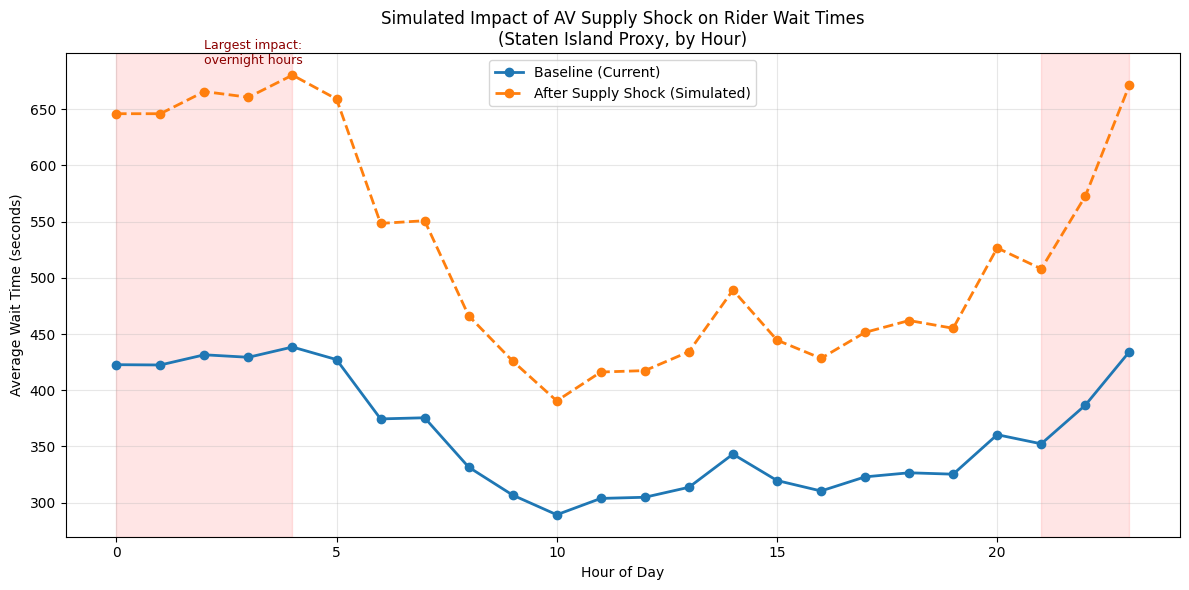

In [31]:
hourly_summary = target_zone_data.groupby("pickup_hour").agg(
    baseline_wait=("avg_wait_sec", "mean"),
    shocked_wait=("predicted_new_wait", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hourly_summary["pickup_hour"], hourly_summary["baseline_wait"], 
        marker='o', label="Baseline (Current)", linewidth=2)
ax.plot(hourly_summary["pickup_hour"], hourly_summary["shocked_wait"], 
        marker='o', label="After Supply Shock (Simulated)", linewidth=2, linestyle='--')

# Highlight worst-hit hours
ax.axvspan(0, 4, alpha=0.1, color='red')
ax.axvspan(21, 23, alpha=0.1, color='red')
ax.annotate('Largest impact:\novernight hours', xy=(2, 690), fontsize=9, color='darkred')

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Wait Time (seconds)")
ax.set_title("Simulated Impact of AV Supply Shock on Rider Wait Times\n(Staten Island Proxy, by Hour)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("wait_time_shock_simulation.png", dpi=150)
plt.show()

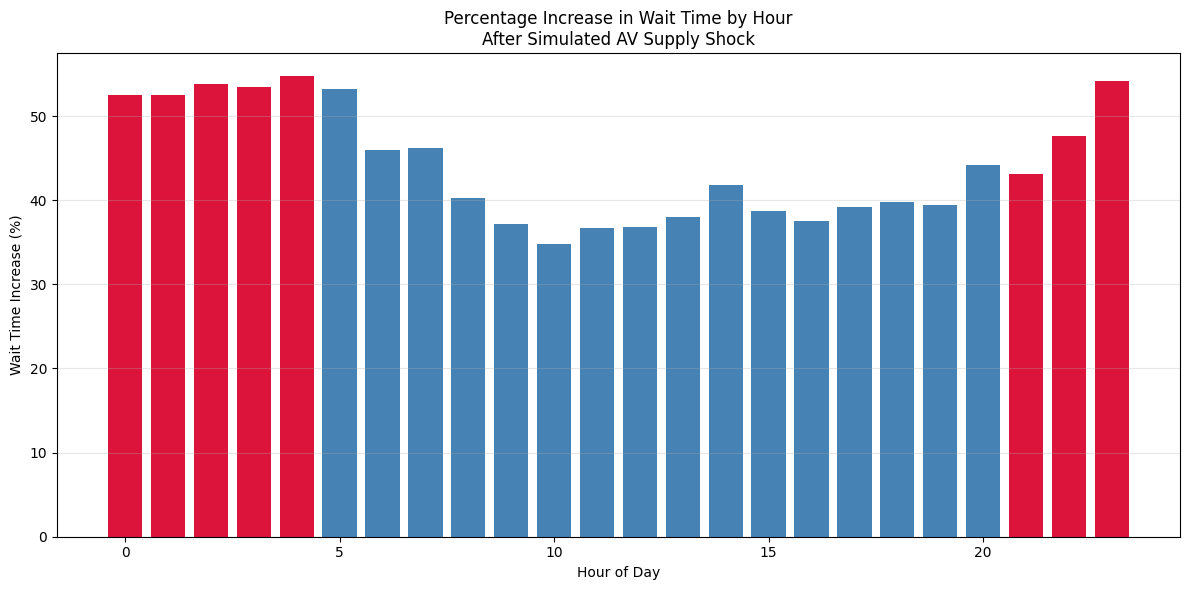

In [32]:
hourly_pct = target_zone_data.groupby("pickup_hour")["pct_wait_increase"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['crimson' if (h <= 4 or h >= 21) else 'steelblue' for h in hourly_pct["pickup_hour"]]
ax.bar(hourly_pct["pickup_hour"], hourly_pct["pct_wait_increase"], color=colors)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Wait Time Increase (%)")
ax.set_title("Percentage Increase in Wait Time by Hour\nAfter Simulated AV Supply Shock")
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("wait_time_pct_increase.png", dpi=150)
plt.show()